## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.003; nt=1000

ntr=201

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

nzsnap=249; nxsnap=249; nsnap=51
def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

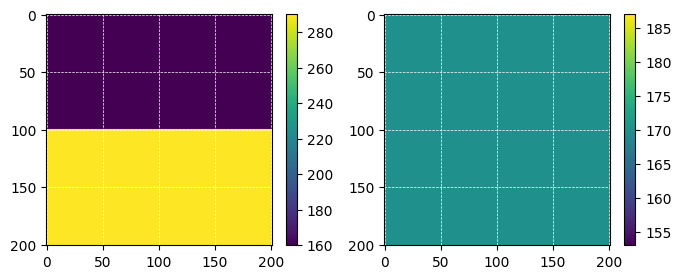

In [2]:
# True
!makevel nz=100 nx=$nx v000=160 > c1
!makevel nz=101 nx=$nx v000=290 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > cel
!rm c1 c2 tmp
#density=0.4*np.pi
!makevel nz=$nz nx=$nx v000=1.25663708 > mu
!cat cel mu > true

# Background
!makevel nz=$nz nx=$nx v000=170 > cel
!cat cel mu > init

#plot
plt.figure(figsize=(8,3))
true=read('true',(2*nx,nz))
init=read('init',(2*nx,nz))
plt.subplot(1,2,1); imshow(true[:,:nx])
plt.subplot(1,2,2); imshow(init[:,:nx])

1.0686971 3.5108366
1.0 1.0


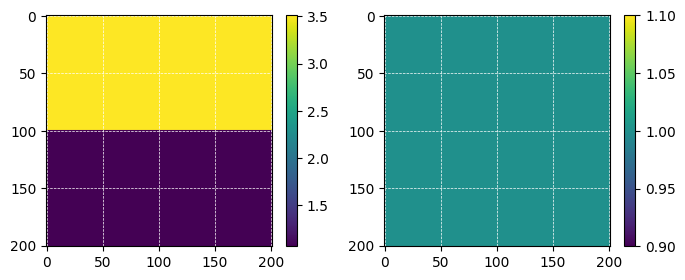

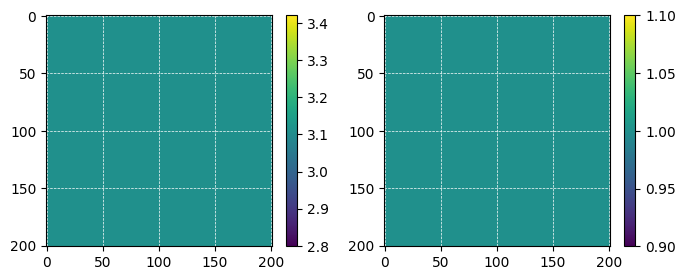

In [3]:
def epsrmur2celmu(epsr,mur):
    cel = 299.79563548 /np.sqrt(epsr*mur)
    mu  = 0.4*np.pi*mur
    return cel,mu

def celmu2epsrmur(cel,mu):
    mur = mu/(0.4*np.pi)
    epsr= (299.79563548/cel)**2/mur
    return epsr,mur

model=read('true',(2*nx,nz))
epsr, mur = celmu2epsrmur(model[:,:nx],model[:,nx:])
model=np.concatenate((epsr,mur),axis=1)
model.T.astype('float32').tofile('true_GPR')

model=read('init',(2*nx,nz))
epsr, mur = celmu2epsrmur(model[:,:nx],model[:,nx:])
model=np.concatenate((epsr,mur),axis=1)
model.T.astype('float32').tofile('init_GPR')


#plot
true=read('true_GPR',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(true[:,:nx]); print(true[:,:nx].min(),true[:,:nx].max())
plt.subplot(1,2,2); imshow(true[:,nx:]); print(true[:,nx:].min(),true[:,nx:].max())

init=read('init_GPR',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(init[:,:nx])
plt.subplot(1,2,2); imshow(init[:,nx:])

In [4]:
#topo
!makevel nz=1   nx=$nx v000=78  > topo

In [9]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '1.5   1.5   1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'true_GPR'
MODEL_ATTRIBUTES        'epsr mur' # sgma'
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '75 75  0'
FR                      '75  0  0'
DR                      '0  1.5 0'
NR                      201

SU_SCALCO   -10

SCOMP                   Ey
RCOMP                   Ey #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           1000
DT           0.003
FPEAK        7

SNAPSHOT                'Ey Hx Hz'


### for inversion ###
FILE_DATA_PREFIX        'results_obs/Ru_Shot'
WEIGHTING               'none'

PARAMETER               'epsr:1.06:3.52'

SMOOTHING               'none'
#PRECO         'z^0'

#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

IF_USE_CHECKPOINT        F

Overwriting setup_default


## TE Ey-Ey

### Obs & Syn data

In [12]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 635424 Jun 26 23:46 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 07/04/2026
System time: 23:24:34
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

In [112]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 635464 Jun 25 12:49 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 50d168c
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 13:50:01
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) o

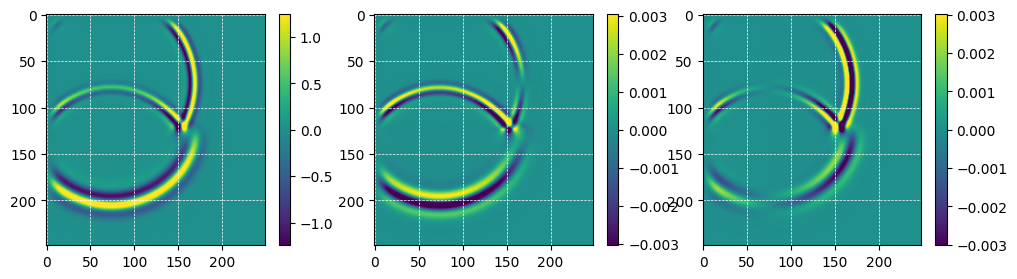

In [13]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_obs/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_obs/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_obs/snap_fld_u%Hz',(51,249,249)),perc=98)

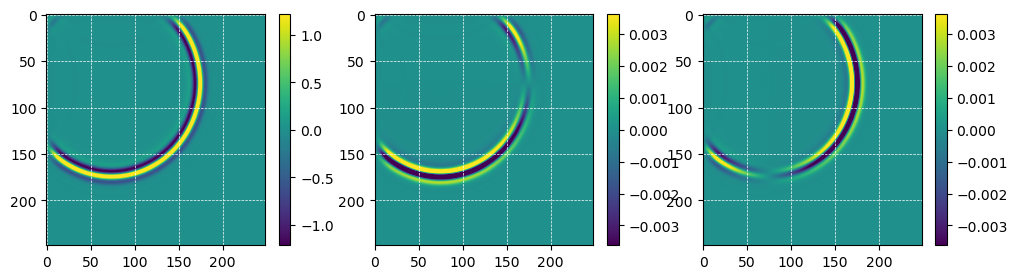

In [28]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_syn/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_syn/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_syn/snap_fld_u%Hz',(51,249,249)),perc=98)

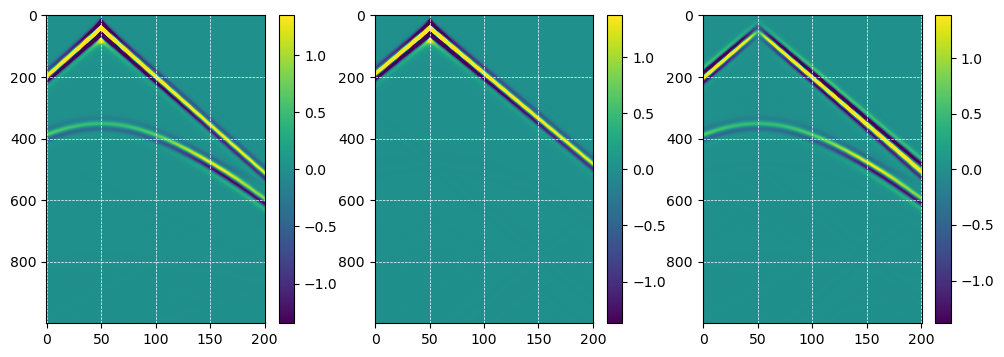

In [29]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su') \
                          -read_su('results_syn/Ru_Shot0001.su'),perc=98)

### Gradient

#### fwi_TE_FDSG_O4_epsr-mur-sgma

In [81]:
!cp setup_default setup
!echo 'FILE_MODEL   init_GPR' >> setup
!echo "PARAMETER   'epsr:1.06:3.52  mur:1:1.2'" >> setup
!echo 'JOB     gradient' >> setup
run(app='../../exe/fwi_TE_FDSG_O4_epsr-mur-sgma_Wolfe_NLCG_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 933448 Jun 25 13:14 ../../exe/fwi_TE_FDSG_O4_epsr-mur-sgma_Wolfe_NLCG_
 Git Commit: 50d168c
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 13:14:57
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *

 it----         500
 fld_a minmax values:  -187.989487       213.167343    
 fld_u minmax values:  -1.72540569       1.54152346    
 Elapsed time to load boundary            7.24416971E-03
 Elapsed time to update E       0.111130059    
 Elapsed time to rm source E     1.79952383E-03
 Elapsed time to update H         0.122708917    
 Total elapsed time for forward (min)   4.04804433E-03
  ---------------------------- 
 Elapsed time to add adjsource E    5.30344248E-03
 Elapsed time to update adj E      0.119026363    
 Elapsed time to update adj H        0.128425062    
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   3.81058455E-03
 Total elapsed time for adjoint&correlate (min)   4.27609077E-03
 Total elapsed time (min):   8.32413509E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 ximage < snap_*  n1=201 perc

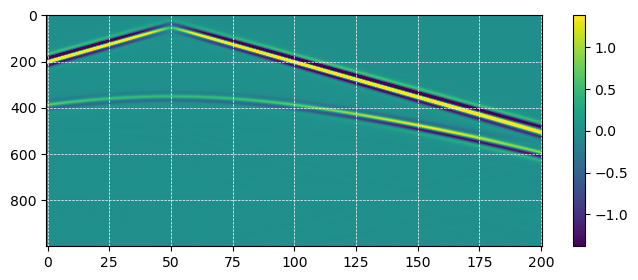

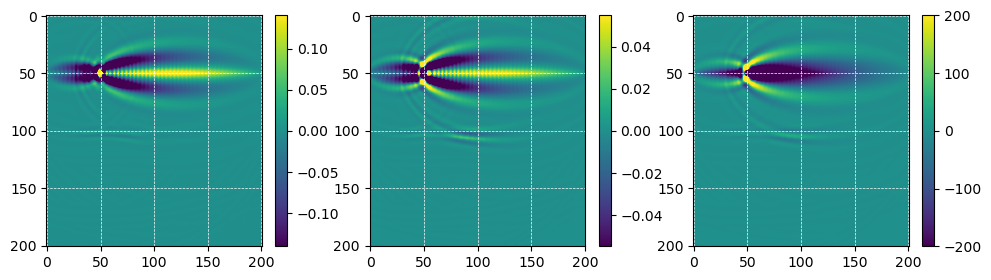

In [82]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98)
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98)
plt.subplot(1,4,3); imshow(corr[:,2*nx:],perc=98)

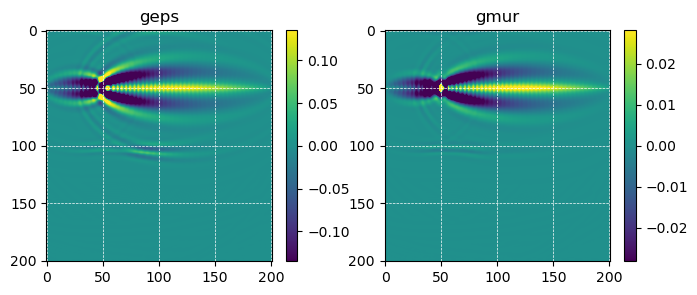

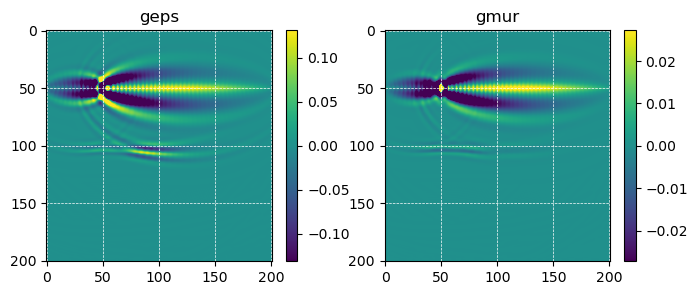

In [84]:
corr=read('results/qp0%g',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='geps')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='gmur')

corr=read('results/qp0%pg',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='geps')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='gmur')

#### fwi_TE_FDSG_O4_celerity-permeability

In [96]:
!cp setup_default setup
!echo 'FILE_MODEL   init_GPR' >> setup
!echo "PARAMETER   'cel:160:290  mu:1.25663708:1.5'" >> setup
!echo "JOB          gradient " >> setup
run(app='../../exe/fwi_TE_FDSG_O4_celerity-permeability_Wolfe_NLCG_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 945736 Jun 25 13:37 ../../exe/fwi_TE_FDSG_O4_celerity-permeability_Wolfe_NLCG_
 Git Commit: 50d168c
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 13:37:42
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef|

 UPDATE_WAVELET is NOT found, take 0, '' or F
 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 DATA_NORM (DNORM) is NOT found, take default: L2
 0.5|| W(f*u - d)||² => adjsrc = f★ W W(f*u - d)
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 remute
 SU data write success.
 ----  Solving adjoint eqn & xcorrelate  ----
 it----        1000
 fld_a minmax values:   0.00000000       0.00000000    
 fld_u minmax values:  -4.78028925E-03   5.19800559E-03
 it----         500
 fld_a minmax values:  -187.989517       213.167511    
 fld_u minmax values:  -1.72540569       1.54152346    
 Elapsed time to load boundary            8.05252790E-03
 Elapsed time to update E       0.123739302    
 Elapsed time to rm source E     2.57718563E-03
 Elapsed time to update H         0.133913457    
 Total elapsed time for forward (min)  

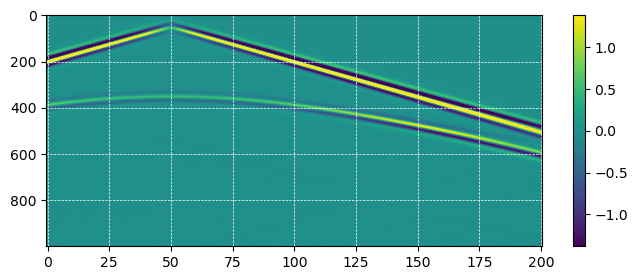

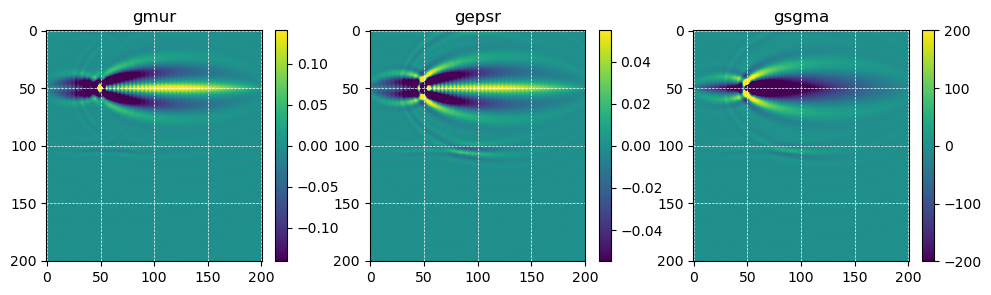

In [97]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],    perc=98,title='gmur')
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98,title='gepsr')
plt.subplot(1,4,3); imshow(corr[:,2*nx:],  perc=98,title='gsgma')

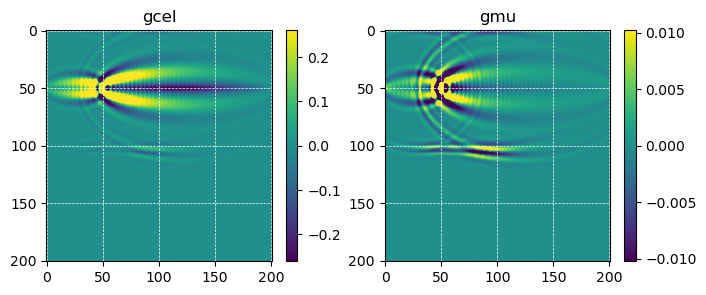

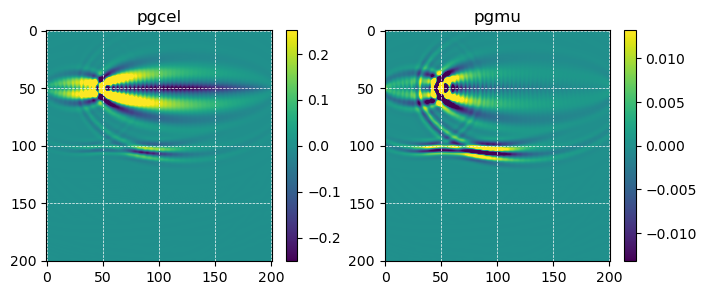

In [98]:
corr=read('results/qp0%g',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='gcel')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='gmu' )

corr=read('results/qp0%pg',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='pgcel')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='pgmu' )

#### fwi_TE_FDSG_O4_celerity-impedance

In [6]:
#"PARAMETER   'cel:160:290  mu:1.25663708:1.5'"
print(160*1.25663708 , 290*1.5)

201.0619328 435.0


In [25]:
!cp setup_default setup
!echo 'FILE_MODEL   init_GPR' >> setup
!echo "PARAMETER   'cel:160:290  imp:201:435'" >> setup
!echo "JOB          gradient " >> setup
run(app='../../exe/fwi_TE_FDSG_O4_celerity-impedance_Wolfe_NLCG_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 954616 Jul  4 23:58 ../../exe/fwi_TE_FDSG_O4_celerity-impedance_Wolfe_NLCG_
 Git Commit: 0f35876
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 07/04/2026
System time: 23:59:03
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax

 UPDATE_WAVELET is NOT found, take 0, '' or F
 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 DATA_NORM (DNORM) is NOT found, take default: L2
 0.5|| W(f*u - d)||² => adjsrc = f★ W W(f*u - d)
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 remute
 SU data write success.
 ----  Solving adjoint eqn & xcorrelate  ----
 it----        1000
 fld_a minmax values:   0.00000000       0.00000000    
 fld_u minmax values:  -4.78028925E-03   5.19800559E-03
 it----         500
 fld_a minmax values:  -187.989517       213.167511    
 fld_u minmax values:  -1.72540569       1.54152346    
 Elapsed time to load boundary            8.05252790E-03
 Elapsed time to update E       0.123739302    
 Elapsed time to rm source E     2.57718563E-03
 Elapsed time to update H         0.133913457    
 Total elapsed time for forward (min)  

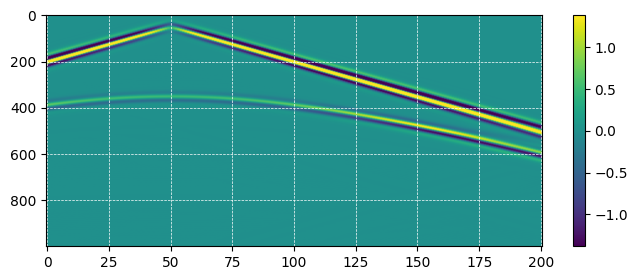

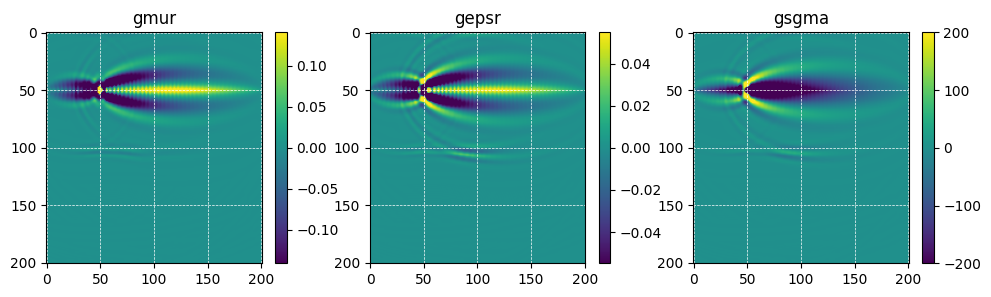

In [23]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],    perc=98,title='gmur')
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98,title='gepsr')
plt.subplot(1,4,3); imshow(corr[:,2*nx:],  perc=98,title='gsgma')

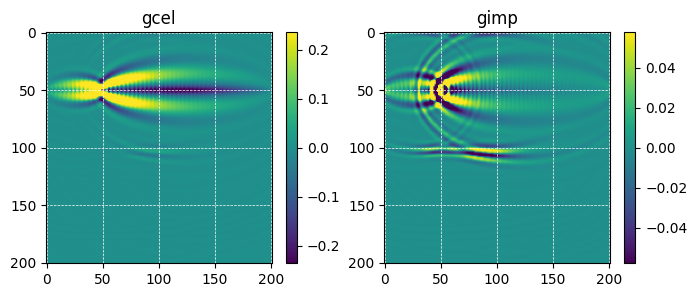

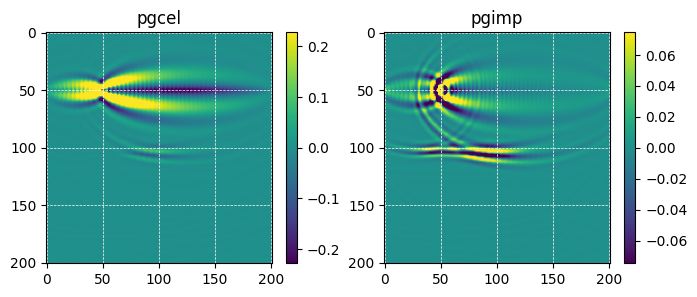

In [26]:
corr=read('results/qp0%g',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='gcel')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='gimp' )

corr=read('results/qp0%pg',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='pgcel')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='pgimp' )

### gradienttest_TE_FDSG_O4_epsr-mur-sgma

In [99]:
!make

#System
(cd ../../Modules/System; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modules/Signal; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Signal'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Signal'
#Modeling
(cd ../../Modules/Modeling; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Modeling'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Modeling'
#Kernel
(cd ../../Modules/Kernel; make App=FWI)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Kernel'
mpif90 -cpp -Dgfortran -D"git_commit='50d168c'" -D"git_branch='GPR'" -Ofast -fopenmp 

#### on gepsr

In [33]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER  'epsr:1.06:3.52'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   1119.54626       1120.42212      -87585.4531      -88921.0469       1.01524901     T
 1st cond   9.99999975E-05   1111.72095       1120.42212      -87011.7188      -88921.0469       1.02194333     T
 1st cond   1.00000005E-03   1036.94934       1120.42212      -83472.7734      -88921.0469       1.06527007     T
 1st cond   9.99999978E-03   655.369995       1120.42212      -46505.2148      -88921.0469       1.91206610     T
 1st cond  0.100000001       706.330078       1120.42212      -4140.92041      -88921.0469       21.4737396     T
 1st cond   1.00000000       1377.86389       1120.42212       257.441772      -88921.0469      -345.402557     F


In [37]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER  'epsr:1.06:3.52'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   5677280.00       5448193.50      -2.29086515E+10  -4457400.00       1.94572785E-04 F
 1st cond  -9.99999975E-05   5677280.00       5448193.50      -2.29086515E+09  -4457400.00       1.94572774E-03 F
 1st cond  -1.00000005E-03   5677280.00       5448193.50      -229086496.      -4457400.00       1.94572788E-02 F
 1st cond  -9.99999978E-03   5677280.00       5448193.50      -22908650.0      -4457400.00      0.194572791     F
 1st cond -0.100000001       5677280.00       5448193.50      -2290865.00      -4457400.00       1.94572794     F
 1st cond  -1.00000000       5677417.50       5448193.50      -229224.000      -4457400.00       19.4456081     F


#### on gmur

In [117]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'mur:0.5:1.5'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_epsr-mur-sgma  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   3056.94019       3062.06201      -512182.625      -504986.969      0.985951006     T
 1st cond   9.99999975E-05   3011.45239       3062.06201      -506096.219      -504986.969      0.997808218     T
 1st cond   1.00000005E-03   2606.92090       3062.06201      -455141.094      -504986.969       1.10951746     T
 1st cond   9.99999978E-03   1570.37390       3062.06201      -149168.812      -504986.969       3.38533878     T
 1st cond  0.100000001       5133.12109       3062.06201       20710.5898      -504986.969      -24.3830318     F
 1st cond   1.00000000       6643.85010       3062.06201       3581.78809      -504986.969      -140.987396     F


In [120]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
!echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'mur:0.5:1.5'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_epsr-mur-sgma  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   7711.10205       7720.76270      -966064.500      -920281.875      0.952609122     T
 1st cond   9.99999975E-05   7624.41504       7720.76270      -963476.562      -920281.875      0.955167890     T
 1st cond   1.00000005E-03   6792.50391       7720.76270      -928258.750      -920281.875      0.991406620     T
 1st cond   9.99999978E-03   4851.33545       7720.76270      -286942.719      -920281.875       3.20719719     T
 1st cond  0.100000001       5885.30518       7720.76270      -18354.5742      -920281.875       50.1391029     T
 1st cond   1.00000000       6753.05859       7720.76270      -967.704102      -920281.875       950.995117     T


In [118]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
!echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'mur:0.5:1.5'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_epsr-mur-sgma  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   7730.43115       7720.76270      -966845.750      -920281.875      0.951839387     F
 1st cond  -9.99999975E-05   7817.67676       7720.76270      -969140.625      -920281.875      0.949585497     F
 1st cond  -1.00000005E-03   8705.28320       7720.76270      -984520.438      -920281.875      0.934751391     F
 1st cond  -9.99999978E-03   12566.6299       7720.76270      -484586.719      -920281.875       1.89910662     F
 1st cond -0.100000001       12642.7910       7720.76270      -49220.2812      -920281.875       18.6972084     F
 1st cond  -1.00000000       12804.4404       7720.76270      -5083.67773      -920281.875       181.026794     F


### gradienttest_TE_FDSG_O4_celerity-permeability

#### on gcel

In [121]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'cel:160:290'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-permeability  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   10.9498749       10.9501848      -30.9944153      -32.0483322       1.03400350     T
 1st cond   9.99999975E-05   10.9470997       10.9501848      -30.8513641      -32.0483322       1.03879786     T
 1st cond   1.00000005E-03   10.9192896       10.9501848      -30.8952312      -32.0483322       1.03732300     T
 1st cond   9.99999978E-03   10.6443987       10.9501848      -30.5786133      -32.0483322       1.04806364     T
 1st cond  0.100000001       8.28424549       10.9501848      -26.6593933      -32.0483322       1.20214033     T
 1st cond   1.00000000       4.98371410       10.9501848      -5.96647072      -32.0483322       5.37140512     T


In [122]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'cel:160:290'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-permeability  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   10.9504766       10.9501848      -29.1824341      -32.0483322       1.09820628     F
 1st cond  -9.99999975E-05   10.9532728       10.9501848      -30.8799744      -32.0483322       1.03783548     F
 1st cond  -1.00000005E-03   10.9811411       10.9501848      -30.9562664      -32.0483322       1.03527772     F
 1st cond  -9.99999978E-03   11.2629595       10.9501848      -31.2774658      -32.0483322       1.02464604     F
 1st cond -0.100000001       14.3691130       10.9501848      -34.1892815      -32.0483322      0.937379539     F
 1st cond  -1.00000000       51.1946678       10.9501848      -40.2444839      -32.0483322      0.796341002     F


#### on gmu

In [123]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'mu:0.6:2.5'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-permeability  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   1636.94751       1642.70081      -575329.625      -622845.188       1.08258843     T
 1st cond   9.99999975E-05   1586.86084       1642.70081      -558399.688      -622845.188       1.11541104     T
 1st cond   1.00000005E-03   1267.47522       1642.70081      -375225.562      -622845.188       1.65992200     T
 1st cond   9.99999978E-03   2271.62866       1642.70081       62892.7852      -622845.188      -9.90328503     F
 1st cond  0.100000001       4201.97656       1642.70081       25592.7578      -622845.188      -24.3367748     F
 1st cond   1.00000000       4818.48877       1642.70081       3175.78809      -622845.188      -196.123032     F


In [124]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
!echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'mu:0.6:2.5'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-permeability  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   3861.52246       3865.68652      -416406.250      -415741.906      0.998404562     T
 1st cond   9.99999975E-05   3824.42065       3865.68652      -412658.688      -415741.906       1.00747156     T
 1st cond   1.00000005E-03   3480.18457       3865.68652      -385501.938      -415741.906       1.07844305     T
 1st cond   9.99999978E-03   3779.51831       3865.68652      -8616.82129      -415741.906       48.2477112     T
 1st cond  0.100000001       4922.58789       3865.68652       10569.0137      -415741.906      -39.3359222     F
 1st cond   1.00000000       5025.37354       3865.68652       1159.68701      -415741.906      -358.494934     F


### gradienttest_TE_FDSG_O4_celerity-impedance

#### on gcel

In [27]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'cel:160:290'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   13.5447292       13.5449886      -25.9399414      -24.7415695      0.953802049     T
 1st cond   9.99999975E-05   13.5424891       13.5449886      -24.9958038      -24.7415695      0.989828944     T
 1st cond   1.00000005E-03   13.5198278       13.5449886      -25.1607876      -24.7415695      0.983338416     T
 1st cond   9.99999978E-03   13.2954159       13.5449886      -24.9572754      -24.7415695      0.991356969     T
 1st cond  0.100000001       11.2163363       13.5449886      -23.2865238      -24.7415695       1.06248450     T
 1st cond   1.00000000       5.63280058       13.5449886      -7.91218805      -24.7415695       3.12701988     T


In [28]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'cel:160:290'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   13.5452280       13.5449886      -23.9372253      -24.7415695       1.03360224     F
 1st cond  -9.99999975E-05   13.5475054       13.5449886      -25.1674652      -24.7415695      0.983077526     F
 1st cond  -1.00000005E-03   13.5701475       13.5449886      -25.1588802      -24.7415695      0.983412981     F
 1st cond  -9.99999978E-03   13.7981424       13.5449886      -25.3153801      -24.7415695      0.977333546     F
 1st cond -0.100000001       16.2350178       13.5449886      -26.9002914      -24.7415695      0.919750988     F
 1st cond  -1.00000000       47.5622635       13.5449886      -34.0172729      -24.7415695      0.727323711     F


#### on gimp

In [30]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'imp:201:435'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

rm: cannot remove 'results': No such file or directory
            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   18.4906693       18.4910717      -40.2450562      -40.6767921       1.01072764     T
 1st cond   9.99999975E-05   18.4873257       18.4910717      -37.4603271      -40.6767921       1.08586323     T
 1st cond   1.00000005E-03   18.4529858       18.4910717      -38.0859375      -40.6767921       1.06802654     T
 1st cond   9.99999978E-03   18.1166916       18.4910717      -37.4380112      -40.6767921       1.08651054     T
 1st cond  0.100000001       16.3212547       18.4910717      -21.6981697      -40.6767921       1.87466466     T
 1st cond   1.00000000       14.8042326       18.4910717      -3.68683910      -40.6767921       11.0329723     T


In [31]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'imp:201:435'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   18.4914265       18.4910717      -35.4766846      -40.6767921       1.14657819     F
 1st cond  -9.99999975E-05   18.4948730       18.4910717      -38.0134583      -40.6767921       1.07006288     F
 1st cond  -1.00000005E-03   18.5292301       18.4910717      -38.1584167      -40.6767921       1.06599796     F
 1st cond  -9.99999978E-03   18.8792477       18.4910717      -38.8175964      -40.6767921       1.04789567     F
 1st cond -0.100000001       22.9623165       18.4910717      -44.7124481      -40.6767921      0.909741998     F
 1st cond  -1.00000000       70.8395081       18.4910717      -52.3484344      -40.6767921      0.777039349     F
